# Online Shoppers Purchasing Intention
#### IE 7275

The goal here is to predict whether a browsing session ends in a purchase (binary target `Revenue`) from in-session browsing behaviour, and identify which digital storefront elements and customer behaviours drive sales.
The [dataset used](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) is the `Online Shoppers Purchasing Intention` dataset by Sakar et al., comprised of 12,330 shopping sessions, 17 predictors, 1 binary target, and a heavy class imbalance with approximately 84.5% of entries resulting in no sale.

Let's start with our imports and getting our data read in.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.utils import resample
from sklearn.metrics import (f1_score, precision_score, recall_score, roc_auc_score,
                             average_precision_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc)

from xgboost import XGBClassifier

In [2]:
global_seed = 7275
np.random.seed(global_seed) # for consistency and reproducibility

df = pd.read_csv("data/online_shoppers_intention.csv")
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
assert(df.isnull().sum().sum() == 0, "missing values in df") # check for missing values
# check for duplicates
assert(df.duplicated().sum() == 0, "duplicate rows in df")
print(df["Revenue"].value_counts())
print((df["Revenue"].value_counts(normalize=True)*100).round(2).astype(str) + " %")

Revenue
False    10422
True      1908
Name: count, dtype: int64
Revenue
False    84.53 %
True     15.47 %
Name: proportion, dtype: object


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


While we don't have missing values, we're going to have to treat those outliers very carefully. The browsing time is measure in seconds, so we can divide by 60 to get a time in minutes, and by 60 again (or 3,600 from the start) to get browsing time in hours. That one entry where a customer viewed a product related page for almost 18 hours straight definitely seems like it's not reliable and shouldn't be counted into typical behaviour! Ideally, we want to account for sessions where the user went AFK. Immediate bounces (times of 0.0 where a user immediately left a page before it finished loading) are fine to keep as they're totally legitimate user behaviour! It's hard to determine a reliable metric for this latter value.
One potential method could be to retain all observations underneath the upper 2-standard error bound (and ignoring the lower bound) across all metrics. There's a few other ways to do this involving more definite frames (i.e. just setting an X minute limit on Y page), but before we do that let's actually look more closely at our data first, starting with our immediate bounces.

In [5]:
dur_cols  = ["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration"]
page_cols = ["Administrative", "Informational", "ProductRelated"]
df["TotalPages"]    = df[page_cols].sum(axis=1)
df["TotalDuration"] = df[dur_cols].sum(axis=1)

has_pages    = df["TotalPages"] > 0
dur_per_page = df["TotalDuration"] / df["TotalPages"].where(has_pages)

zero_dur = (df["TotalPages"] > 0) & (df["TotalDuration"] == 0)
print(f"Sessions with 0 browse time on visited pages: {zero_dur.sum()} ({(df.loc[zero_dur,'TotalPages']==1).sum()} single-page), yielding a revenue conversion rate of {df.loc[zero_dur,'Revenue'].mean():.2%}")

Sessions with 0 browse time on visited pages: 714 (546 single-page), yielding a revenue conversion rate of 0.42%


That looks fine to me, as most really are single-page immediate bounces! What comes next is to evaluate our sessions with unusually long browsing times to see if any of those observations seem to be legitimate browsing sessions, or if they're really just noise in the grand scheme of things.
To start, before we calculate any kind of cutoff point, let's simply use Tukey's method, and evaluate only sessions with browsing durations that fall above the extreme outer fence. Specifically, let's compare the conversion rates of browsing sessions with durations exceeding the 75th percentile by more than 3 times the interquartile range to our overall average conversion rate.

In [6]:
q1, q3 = dur_per_page.quantile([.25, .75]); fence = q3 + 3*(q3 - q1)
above = (dur_per_page > fence) & has_pages
print(f"Number of sessions above the outer fence: {above.sum()} ({above.mean():.2%} of all sessions)")
print(f"Conversion rate above the outer fence: {df.loc[above,'Revenue'].mean():.1%} ")
print(f"Overall conversion rate: {df['Revenue'].mean():.1%}")


Number of sessions above the outer fence: 285 (2.31% of all sessions)
Conversion rate above the outer fence: 10.9% 
Overall conversion rate: 15.5%


In most cases, users who are truly extremely engaged with their shopping could be expected to have a higher conversion rate. Unfortunately, these users have significantly lower conversion rates. 

As this is still a WIP, before I settle on further steps to take regarding these observations, let's do some EDA, then some base model fitting based on all the data for the time being. 

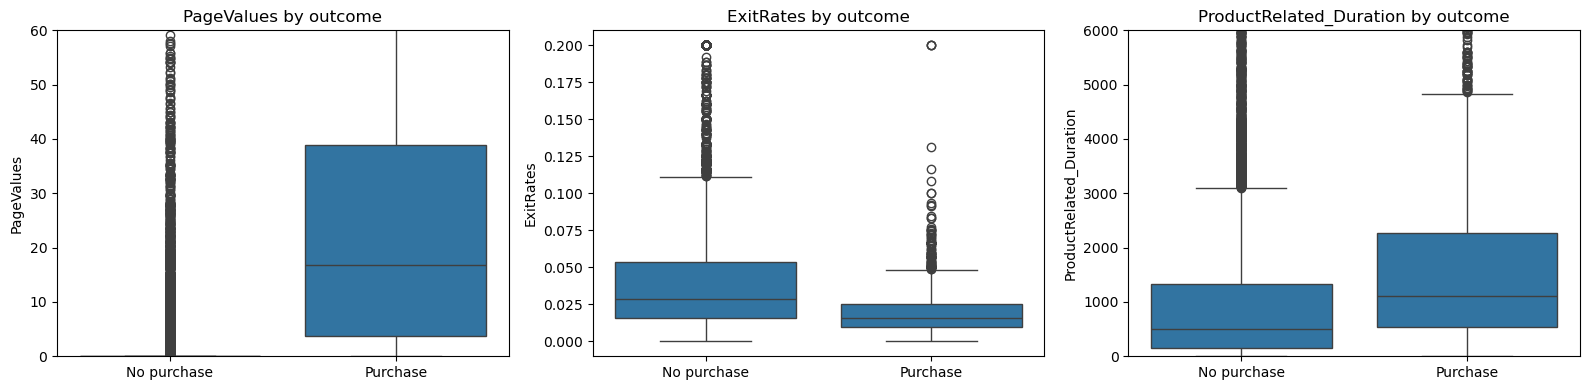

In [7]:
df_e = df.assign(Revenue_lbl=df["Revenue"].map({False:"No purchase", True:"Purchase"}))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df_e, x="Revenue_lbl", y="PageValues", ax=axes[0]); axes[0].set_ylim(0,60); axes[0].set_title("PageValues by outcome")
sns.boxplot(data=df_e, x="Revenue_lbl", y="ExitRates",  ax=axes[1]); axes[1].set_title("ExitRates by outcome")
sns.boxplot(data=df_e, x="Revenue_lbl", y="ProductRelated_Duration", ax=axes[2]); axes[2].set_ylim(0,6000); axes[2].set_title("ProductRelated_Duration by outcome")
for a in axes: a.set_xlabel("")
plt.tight_layout(); plt.show()

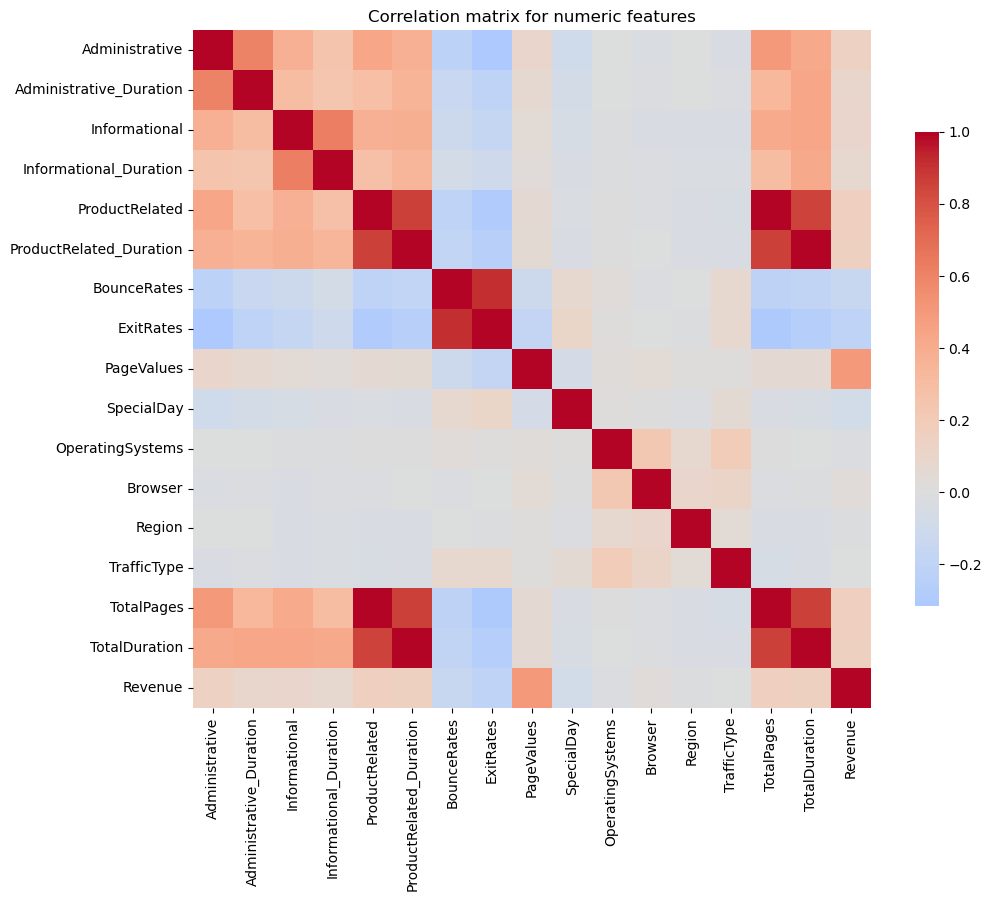

Most correlated pairs:
 ProductRelated           TotalPages                 0.997
ProductRelated_Duration  TotalDuration              0.994
BounceRates              ExitRates                  0.913
ProductRelated           ProductRelated_Duration    0.861
dtype: float64


In [8]:
num = df.select_dtypes("number").assign(Revenue=df["Revenue"].astype(int))
corr = num.corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink":.7})
plt.title("Correlation matrix for numeric features"); plt.tight_layout(); plt.show()
upper = corr.abs().where(np.triu(np.ones(corr.shape),1).astype(bool)).stack().sort_values(ascending=False)
print("Most correlated pairs:\n", upper.head(4).round(3))

Somewhat unsurprisingly, the total number of pages visited is highly correlated with the number of products viewed, the amount of time spent browsing those products, and the total amount of time spent browsing pages. Bounce rates and exit rates are also highly correlated with one another. 

For modelling purposes, we'll need to perform a stratified split on our dataset to preserve class ratios in our training and test splits, but we'll need two versions of the data encoded differently. As such, we can set up two different pipelines that we can call later. For logistic models, such as our baseline logit and LASSO models, we'll need scaled, standardized numeric features. Those won't be needed for our decision tree based models (RF and XGB), though, so let's make these two different versions first.

Note that due to the nature of one-hot encoding, we'll be adding a lot more features to the dataset.

In [9]:
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)
cat_cols = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
for c in cat_cols:
    df[c] = df[c].astype(str)

y = df["Revenue"]
X = df.drop(columns=["Revenue"])
num_cols = [c for c in X.columns if c not in cat_cols]

# 80-20 stratified split using our global seed for reproducibility
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=global_seed)
print(f"Train {X_tr.shape} (pos {y_tr.mean():.1%})   Test {X_te.shape} (pos {y_te.mean():.1%})")

# basic pipeline for tree-based models (one-hot encoding factors with no scaling of numerics)
ohe = lambda: OneHotEncoder(handle_unknown="ignore", sparse_output=False)
pre_raw    = ColumnTransformer([("num", "passthrough", num_cols), ("cat", ohe(), cat_cols)])

# scaled pipeline for the logistic models
pre_scaled = ColumnTransformer([("num", StandardScaler(), num_cols), ("cat", ohe(), cat_cols)])
print(f"{len(num_cols)} numeric + {len(cat_cols)} categorical predictors ")

Train (9864, 19) (pos 15.5%)   Test (2466, 19) (pos 15.5%)
13 numeric + 6 categorical predictors 


Before we call our pipelines later, we can just quickly test them to see how many columns we will wind up with afterwards.

In [10]:
X_tr_transformed = pre_raw.fit_transform(X_tr)

print(f"Shape before pipeline: {X_tr.shape}")
print(f"Shape AFTER pipeline: {X_tr_transformed.shape}")

Shape before pipeline: (9864, 19)
Shape AFTER pipeline: (9864, 76)


So we'll be leaping from 19 to 76 columns. Wow. Next, let's randomly oversample our training set so we have balanced classes in our training data, while leaving our test set untouched to avoid data leakage.

In [11]:
def oversample(Xd, yd, seed=global_seed):
    d = Xd.copy(); d["_y"] = yd.values
    pos, neg = d[d._y == 1], d[d._y == 0]
    up = resample(pos, replace=True, n_samples=len(neg), random_state=seed)
    out = pd.concat([neg, up]).sample(frac=1, random_state=seed)
    return out.drop(columns="_y"), out["_y"]

In [12]:
X_bal, y_bal = oversample(X_tr, y_tr)
print(f"Oversampled training set: {X_bal.shape} with class ratios of {y_bal.value_counts(normalize=True).to_dict()}")

Oversampled training set: (16676, 19) with class ratios of {1: 0.5, 0: 0.5}


We can start with our modelling, beginning with a basic unregularized logit model to compare later models to. 

In [13]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=global_seed) # consistent folds across models by seed, always 10 splits
results = {}
test_proba = {}   # store positive-class probabilities for curves later

def evaluate_proba(name, proba, thresh=0.5):
    proba = np.asarray(proba); pred = (proba >= thresh).astype(int) # pos-class probabilities to 1-D array; pred thresholds then casts to binary class
    results[name] = {"F1": f1_score(y_te, pred), "Precision": precision_score(y_te, pred),
                     "Recall": recall_score(y_te, pred), "ROC_AUC": roc_auc_score(y_te, proba),
                     "PR_AUC": average_precision_score(y_te, proba)}
    test_proba[name] = proba # store for later use in curves
    print(f"{name}:  F1={results[name]['F1']:.3f}  Precision={results[name]['Precision']:.3f}  "
          f"Recall={results[name]['Recall']:.3f}  ROC-AUC={results[name]['ROC_AUC']:.3f}  "
          f"PR-AUC={results[name]['PR_AUC']:.3f}")

In [14]:
# unregularized logit
logit_base = Pipeline([("pre", pre_scaled),
                       ("clf", LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000))]).fit(X_bal, y_bal) # lbfgs = Limited-memory Broyden–Fletcher–Goldfarb–Shanno algorithm
                                                                                                                    # default solver for sklearn
evaluate_proba("Logistic (baseline)", logit_base.predict_proba(X_te)[:, 1])

Logistic (baseline):  F1=0.629  Precision=0.532  Recall=0.770  ROC-AUC=0.911  PR-AUC=0.661


In [15]:
lasso_grid = GridSearchCV(
    Pipeline([("pre", pre_scaled),
              ("clf", LogisticRegression(penalty="l1", solver="liblinear", max_iter=3000,
                                         class_weight="balanced", random_state=global_seed))]), # using class weight in lieu of oversampling to avoid data leakage across folds
    {"clf__C": np.logspace(-3, 1, 50)}, scoring="neg_log_loss", cv=cv, n_jobs=-1).fit(X_tr, y_tr) # retrieves highest C value that yields the best F1 score across our folds
# C is the inverse of regularization strength
print("Best C:", lasso_grid.best_params_["clf__C"])
evaluate_proba("LASSO min", lasso_grid.best_estimator_.predict_proba(X_te)[:, 1]) # our lambda.min lasso results

Best C: 0.2811768697974228
LASSO min:  F1=0.634  Precision=0.541  Recall=0.767  ROC-AUC=0.912  PR-AUC=0.663


In [16]:
cvr  = pd.DataFrame(lasso_grid.cv_results_) # cross validation results from our grid search
best = cvr["mean_test_score"].idxmax()
# manually implenment lambda.1se from R
se   = cvr.loc[best, "std_test_score"] / np.sqrt(cv.get_n_splits()) # obtaining the standard error using s/sqrt(n)
within = cvr["mean_test_score"] >= cvr.loc[best, "mean_test_score"] - se # within the 1se band of the best mean CV score
C_1se  = cvr.loc[within, "param_clf__C"].min() # getting the smallest C val within our bounds
dev_min = -cvr.loc[best, "mean_test_score"] # flip log loss sign
print(f"lambda.min  -> C = {lasso_grid.best_params_['clf__C']:.4g}  (mean CV deviance = {dev_min:.3f})")
print(f"1-SE band   -> mean CV deviance <= {dev_min + se:.3f}")
print(f"lambda.1se  -> C = {C_1se:.4g}")

lasso_1se = clone(lasso_grid.best_estimator_).set_params(clf__C=C_1se).fit(X_tr, y_tr)
n_min = (lasso_grid.best_estimator_.named_steps["clf"].coef_[0] != 0).sum()
n_1se = (lasso_1se.named_steps["clf"].coef_[0] != 0).sum()
print(f"Features comparison: lambda.min = {n_min} features retained vs {n_1se} for lambda.1se")
evaluate_proba("LASSO (1se)", lasso_1se.predict_proba(X_te)[:, 1]) # our lambda.1se lasso results

lambda.min  -> C = 0.2812  (mean CV deviance = 0.442)
1-SE band   -> mean CV deviance <= 0.449
lambda.1se  -> C = 0.02024
Features comparison: lambda.min = 42 features retained vs 17 for lambda.1se
LASSO (1se):  F1=0.653  Precision=0.569  Recall=0.764  ROC-AUC=0.914  PR-AUC=0.666


In [17]:
rf_grid = GridSearchCV(
    Pipeline([("pre", pre_raw),
              ("clf", RandomForestClassifier(class_weight="balanced", random_state=global_seed, n_jobs=-1))]), # balanced bc we've oversampled and classes in train data are no longer imbalanced
    {"clf__n_estimators": [300, 500], "clf__max_depth": [None, 12, 20]},
    scoring="f1", cv=cv, n_jobs=-1).fit(X_tr, y_tr)
print("Best params:", rf_grid.best_params_)
evaluate_proba("Random forest", rf_grid.best_estimator_.predict_proba(X_te)[:, 1])

Best params: {'clf__max_depth': 12, 'clf__n_estimators': 500}
Random forest:  F1=0.674  Precision=0.592  Recall=0.783  ROC-AUC=0.930  PR-AUC=0.737


In [18]:
spw = (y_tr == 0).sum() / (y_tr == 1).sum() # neg:pos ratio in ORIGINAL train set for scale_pos_weight in XGBoost
xgb = XGBClassifier(objective="binary:logistic", eval_metric="logloss", # binary classification, and logless is the default evaluation metric
                    tree_method="hist", scale_pos_weight=spw, # histogram method for trees by binning continuous features discretely
                    # spw helps XGBoost handle class imbalance by weighting the positive class more heavily in the loss function
                    random_state=global_seed, n_jobs=-1)
xgb_grid = GridSearchCV(
    Pipeline([("pre", pre_raw), ("clf", xgb)]), # using our raw, non-oversampled data!
    {"clf__n_estimators": [300, 500],
     "clf__max_depth":    [3, 6],
     "clf__learning_rate":[0.05, 0.1],
     "clf__subsample":    [0.9]},
    scoring="f1", cv=cv, n_jobs=-1).fit(X_tr, y_tr)
print("Best params:", xgb_grid.best_params_)
evaluate_proba("XGBoost", xgb_grid.best_estimator_.predict_proba(X_te)[:, 1])

Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__n_estimators': 300, 'clf__subsample': 0.9}
XGBoost:  F1=0.688  Precision=0.605  Recall=0.798  ROC-AUC=0.936  PR-AUC=0.752


In [19]:
res = pd.DataFrame(results).T.sort_values("F1", ascending=False)
res.round(3)

,F1,Precision,Recall,ROC_AUC,PR_AUC
XGBoost,0.688,0.605,0.798,0.936,0.752
Random forest,0.674,0.592,0.783,0.930,0.737
LASSO (1se),0.653,0.569,0.764,0.914,0.666
LASSO min,0.634,0.541,0.767,0.912,0.663
Logistic (baseline),0.629,0.532,0.770,0.911,0.661
